 ### Anomaly Detection

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


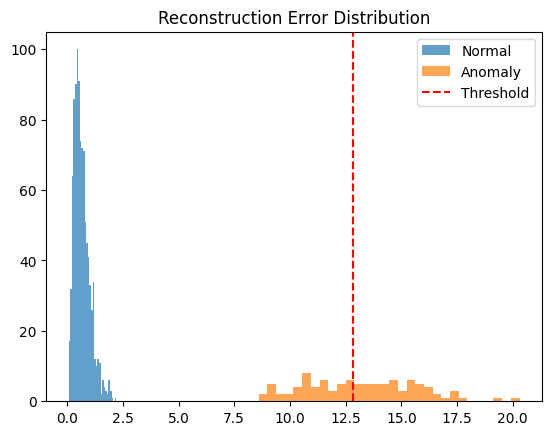

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# Generate synthetic data (normal and anomalous samples)
normal_data = np.random.normal(0, 1, (1000, 10))
anomalous_data = np.random.normal(5, 1, (100, 10))  # Shifted mean for anomaly
data = np.vstack([normal_data, anomalous_data])
labels = np.hstack([np.zeros(1000), np.ones(100)])  # 0 for normal, 1 for anomaly

# Split data into training (normal data only) and testing sets
X_train, X_test, y_train, y_test = train_test_split(normal_data, labels[:1000], test_size=0.3, random_state=42)

# Build the autoencoder
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation="relu")(input_layer)
encoded = Dense(4, activation="relu")(encoded)
decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Train the autoencoder
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate on test data
reconstructions = autoencoder.predict(data)
reconstruction_error = np.mean(np.square(reconstructions - data), axis=1)

# Plot reconstruction error
plt.hist(reconstruction_error[labels == 0], bins=30, alpha=0.7, label="Normal")
plt.hist(reconstruction_error[labels == 1], bins=30, alpha=0.7, label="Anomaly")
plt.axvline(x=np.percentile(reconstruction_error, 95), color='red', linestyle='--', label="Threshold")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


### Data Denoising

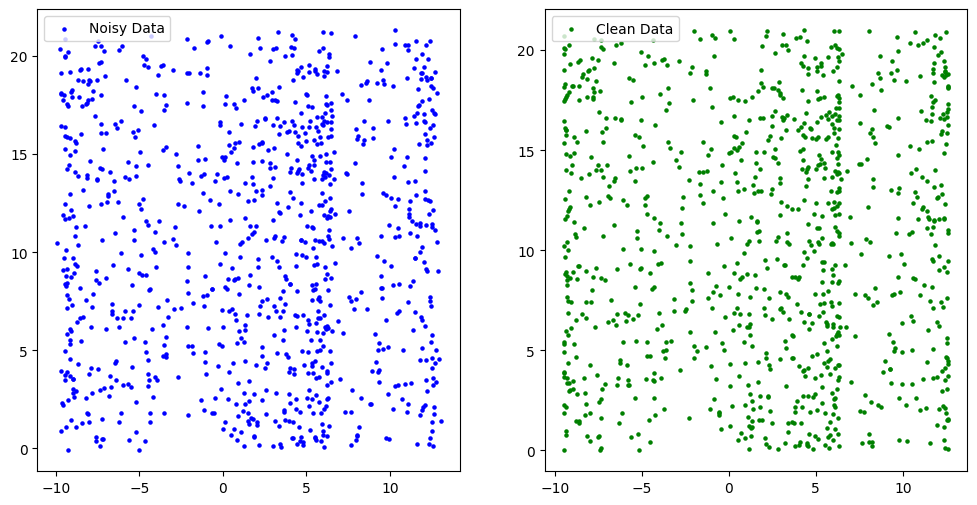

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


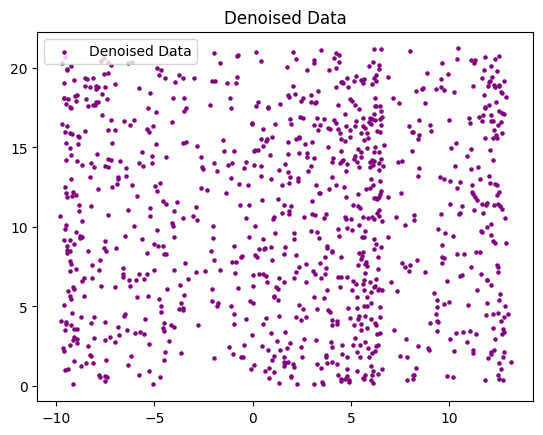

In [2]:
# Generate synthetic noisy and clean data
from sklearn.datasets import make_swiss_roll
clean_data, _ = make_swiss_roll(n_samples=1000, noise=0.0)
noise = np.random.normal(0, 0.2, clean_data.shape)
noisy_data = clean_data + noise

# Visualize noisy and clean data
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(noisy_data[:, 0], noisy_data[:, 1], c="blue", s=5, label="Noisy Data")
axs[0].legend()
axs[1].scatter(clean_data[:, 0], clean_data[:, 1], c="green", s=5, label="Clean Data")
axs[1].legend()
plt.show()

# Build the autoencoder
input_dim = noisy_data.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

denoising_autoencoder = Model(inputs=input_layer, outputs=decoded)
denoising_autoencoder.compile(optimizer="adam", loss="mse")

# Train the autoencoder
denoising_autoencoder.fit(noisy_data, clean_data, epochs=100, batch_size=32, verbose=0)

# Denoise the data
denoised_data = denoising_autoencoder.predict(noisy_data)

# Visualize the denoised data
plt.scatter(denoised_data[:, 0], denoised_data[:, 1], c="purple", s=5, label="Denoised Data")
plt.legend()
plt.title("Denoised Data")
plt.show()


### Dimensionality Reduction

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


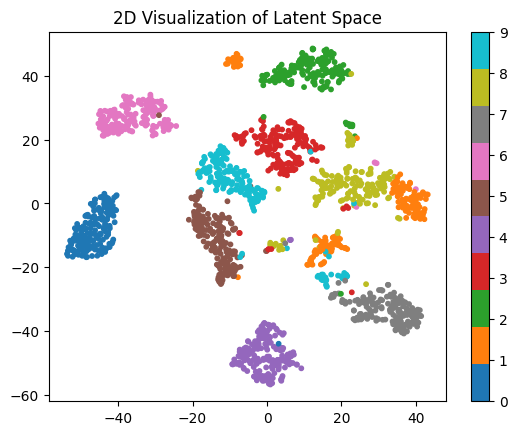

In [3]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Normalize the data
X = X / 16.0

# Build the autoencoder
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)  # Latent space
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

dim_reduction_autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)  # Encoder for dimensionality reduction
dim_reduction_autoencoder.compile(optimizer="adam", loss="mse")

# Train the autoencoder
dim_reduction_autoencoder.fit(X, X, epochs=50, batch_size=32, verbose=0)

# Obtain the latent representation
latent_representation = encoder.predict(X)

# Visualize the latent space using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(latent_representation)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10)
plt.colorbar()
plt.title("2D Visualization of Latent Space")
plt.show()


### Restricted Boltzmann Machines (RBMs) for Collaborative Filtering and Recommendation Systems​

### Live Virtual Class Content: Using Restricted Boltzmann Machines (RBMs) for Collaborative Filtering and Recommendation Systems

---


**How RBMs Work for Collaborative Filtering**  
- The visible layer of the RBM represents the user-item interactions, such as ratings or clicks.  
- The hidden layer learns latent features that represent user preferences and item characteristics.  
- During training, the RBM learns to reconstruct the visible layer, capturing meaningful patterns.  
- Once trained, the hidden layer’s activations can be used to predict missing interactions, such as unrated items for users.

**Key Steps in Implementation**  
1. **Data Preparation**: Preprocess user-item interaction data into a binary or normalized format.  
2. **Model Setup**: Define the RBM architecture with visible and hidden layers.  
3. **Training**: Use Contrastive Divergence to optimize the weights and biases.  
4. **Prediction**: Use the trained RBM to predict user preferences for unrated items.

---

### **Implementation: RBM for Collaborative Filtering**


In [4]:

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

# Generate synthetic user-item interaction data
# Users: rows, Items: columns
np.random.seed(42)
num_users = 100
num_items = 50
interaction_matrix = np.random.randint(0, 2, size=(num_users, num_items))  # Binary interactions (0: not interacted, 1: interacted)

# Split data into training and testing sets
train_data, test_data = train_test_split(interaction_matrix, test_size=0.2, random_state=42)

# Define RBM parameters
num_visible = train_data.shape[1]  # Number of visible units (items)
num_hidden = 64  # Number of hidden units (latent features)
learning_rate = 0.01
epochs = 50

# Initialize weights and biases
weights = np.random.normal(0, 0.01, (num_visible, num_hidden))
visible_bias = np.zeros(num_visible)
hidden_bias = np.zeros(num_hidden)

# Define sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Training the RBM using Contrastive Divergence
for epoch in range(epochs):
    for user in train_data:
        # Positive phase
        hidden_prob = sigmoid(np.dot(user, weights) + hidden_bias)
        hidden_states = (hidden_prob > np.random.rand(num_hidden)).astype(float)
        pos_associations = np.outer(user, hidden_prob)

        # Negative phase
        visible_prob = sigmoid(np.dot(hidden_states, weights.T) + visible_bias)
        visible_states = (visible_prob > np.random.rand(num_visible)).astype(float)
        hidden_prob_neg = sigmoid(np.dot(visible_states, weights) + hidden_bias)

        # Update weights and biases
        neg_associations = np.outer(visible_states, hidden_prob_neg)
        weights += learning_rate * (pos_associations - neg_associations)
        visible_bias += learning_rate * (user - visible_states)
        hidden_bias += learning_rate * (hidden_prob - hidden_prob_neg)

    # Log progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} complete.")

# Predict missing items for a test user
test_user = test_data[0]
hidden_prob = sigmoid(np.dot(test_user, weights) + hidden_bias)
reconstructed_ratings = sigmoid(np.dot(hidden_prob, weights.T) + visible_bias)

# Recommend top items
recommended_items = np.argsort(-reconstructed_ratings)[:5]
print(f"Recommended items for the test user: {recommended_items}")

Epoch 10/50 complete.
Epoch 20/50 complete.
Epoch 30/50 complete.
Epoch 40/50 complete.
Epoch 50/50 complete.
Recommended items for the test user: [33  8  6 25 40]




### **Explanation of Code**

1. **Data Preparation**  
   - The user-item interaction matrix is generated or loaded from real-world data.  
   - The matrix is split into training and testing sets to evaluate the model's performance.

2. **Model Setup**  
   - The RBM architecture is defined with a visible layer corresponding to the number of items and a hidden layer to learn latent features.

3. **Training**  
   - Contrastive Divergence is used to train the RBM. The positive phase computes associations between visible and hidden layers, while the negative phase reconstructs visible units and updates the weights and biases.

4. **Prediction**  
   - After training, the RBM predicts ratings for unrated items by reconstructing the visible layer. Top-N recommendations are generated based on the highest predicted ratings.

---

### **Visualizing Recommendations**

**Visualizing Results**  
- Use a bar chart to display the reconstructed ratings for items, highlighting the top recommendations.  


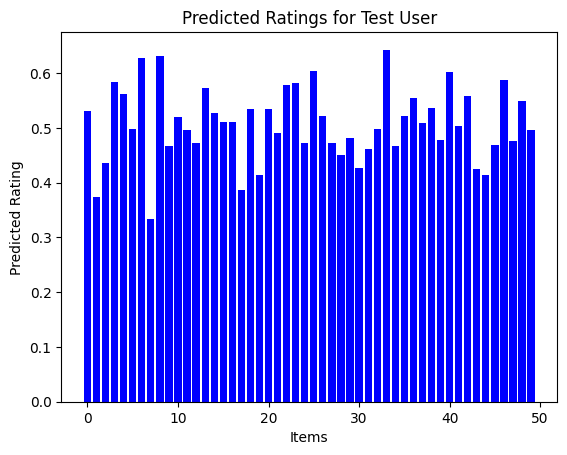

In [5]:

import matplotlib.pyplot as plt

# Visualize the predicted ratings
plt.bar(range(len(reconstructed_ratings)), reconstructed_ratings, color='blue')
plt.xlabel('Items')
plt.ylabel('Predicted Rating')
plt.title('Predicted Ratings for Test User')
plt.show()

### Hands-on Implementation of Deep Belief Networks (DBNs)


**Use Case 1: Feature Extraction**  
DBNs can extract meaningful features from raw data by learning latent representations at multiple layers. These features are more compact and informative, improving the performance of supervised learning algorithms.

**Use Case 2: Data Pre-Processing**  
By transforming raw data into a lower-dimensional latent space, DBNs can remove noise and reduce dimensionality, preparing the data for efficient and effective modeling.

---

### **Implementation: Feature Extraction Using DBNs**

In [6]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load and preprocess data
digits = load_digits()
X = digits.data
y = digits.target

# Normalize the data to the range [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build a DBN using stacked RBMs
class RBM:
    def __init__(self, n_visible, n_hidden):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.W = np.random.normal(0, 0.01, (n_visible, n_hidden))  # Weight matrix
        self.b_visible = np.zeros(n_visible)  # Visible bias
        self.b_hidden = np.zeros(n_hidden)  # Hidden bias

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, data, epochs=10, learning_rate=0.01):
        for epoch in range(epochs):
            for sample in data:
                # Positive phase
                hidden_prob = self.sigmoid(np.dot(sample, self.W) + self.b_hidden)
                hidden_state = (hidden_prob > np.random.rand(self.n_hidden)).astype(float)
                pos_associations = np.outer(sample, hidden_prob)

                # Negative phase
                visible_prob = self.sigmoid(np.dot(hidden_state, self.W.T) + self.b_visible)
                visible_state = (visible_prob > np.random.rand(self.n_visible)).astype(float)
                hidden_prob_neg = self.sigmoid(np.dot(visible_state, self.W) + self.b_hidden)
                neg_associations = np.outer(visible_state, hidden_prob_neg)

                # Update weights and biases
                self.W += learning_rate * (pos_associations - neg_associations)
                self.b_visible += learning_rate * (sample - visible_state)
                self.b_hidden += learning_rate * (hidden_prob - hidden_prob_neg)

    def transform(self, data):
        hidden_prob = self.sigmoid(np.dot(data, self.W) + self.b_hidden)
        return hidden_prob

# Train the first RBM
rbm1 = RBM(n_visible=X_train.shape[1], n_hidden=128)
rbm1.train(X_train, epochs=10)

# Transform the data to latent space of the first RBM
X_train_rbm1 = rbm1.transform(X_train)
X_test_rbm1 = rbm1.transform(X_test)

# Train the second RBM on the latent space of the first RBM
rbm2 = RBM(n_visible=128, n_hidden=64)
rbm2.train(X_train_rbm1, epochs=10)

# Transform the data to the latent space of the second RBM
X_train_rbm2 = rbm2.transform(X_train_rbm1)
X_test_rbm2 = rbm2.transform(X_test_rbm1)

# Train a classifier on the extracted features
classifier = LogisticRegression()
classifier.fit(X_train_rbm2, y_train)

# Evaluate the classifier
y_pred = classifier.predict(X_test_rbm2)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Accuracy: 0.81



### **Explanation of Code**

1. **Data Preprocessing**  
   - The dataset is normalized to bring the values into the range [0, 1]. This is important for the sigmoid activation function used in RBMs.

2. **Building and Training the First RBM**  
   - The first RBM is trained on the raw input data. After training, the latent representation is extracted, representing meaningful features of the input.

3. **Stacking the Second RBM**  
   - The output of the first RBM is used as input to the second RBM. This hierarchical feature extraction enables the DBN to learn progressively abstract representations.

4. **Classifier Training**  
   - The latent representations from the second RBM are used to train a logistic regression classifier, demonstrating the DBN’s effectiveness in feature extraction.

5. **Evaluation**  
   - The classifier is evaluated on test data, showing how the features learned by the DBN improve classification performance.

---

### **Implementation: Data Pre-Processing Using DBNs**


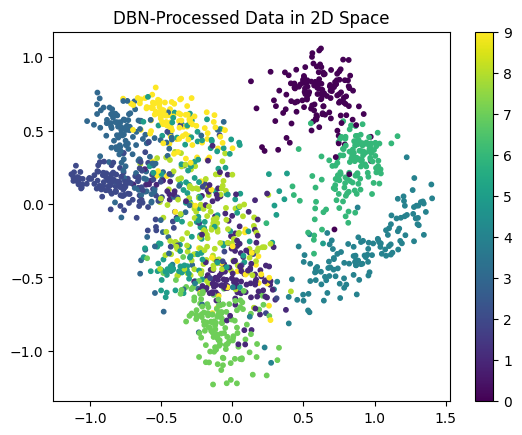

In [9]:

from sklearn.decomposition import PCA

# Apply PCA to the latent features from the second RBM
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_rbm2)
X_test_pca = pca.transform(X_test_rbm2)

# Visualize the pre-processed data
import matplotlib.pyplot as plt

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', s=10)
#plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', s=10)
plt.colorbar()
plt.title("DBN-Processed Data in 2D Space")
plt.show()



1. **Visualization of Latent Features**  
   - The features learned by the DBN are further reduced to 2D using PCA for visualization. This demonstrates the effectiveness of DBNs in pre-processing data for easier interpretation.

2. **Improved Downstream Task Performance**  
   - The pre-processed data can now be used for clustering or classification tasks, improving efficiency and accuracy.
